# Superstore Churn 1.02: IMPROVED Feature Engineering Setup

**Version 0.2 — Feature improvements from Claude dialog**

by Jason "Scott" Person

[Data Science @ Newman University](https://newmanu.edu/academics/graduate-programs/ms-data-science)


## Changes in v0.2
- Dropped `Row ID_count` (redundant with `order_count`)
- Dropped `Sales_sum` and `Profit_sum` (highly correlated with means)
- Added `tenure_days` (days from first order to reference date)
- Added `profit_margin` (Profit / Sales ratio per customer)
- Added gap_trend coverage reporting before NaN fill
- Fixed `market_dummies` to use `dtype=int` at creation instead of post-conversion

## Here is the process we will follow
[Download the flowchart - PNG image](https://1drv.ms/i/c/35b6a879f6dd9905/EdXwp5VFcP9JnIt3epTskPABP8COB5eD7ZVpzMuWUA42Cw?e=zLxVlO)


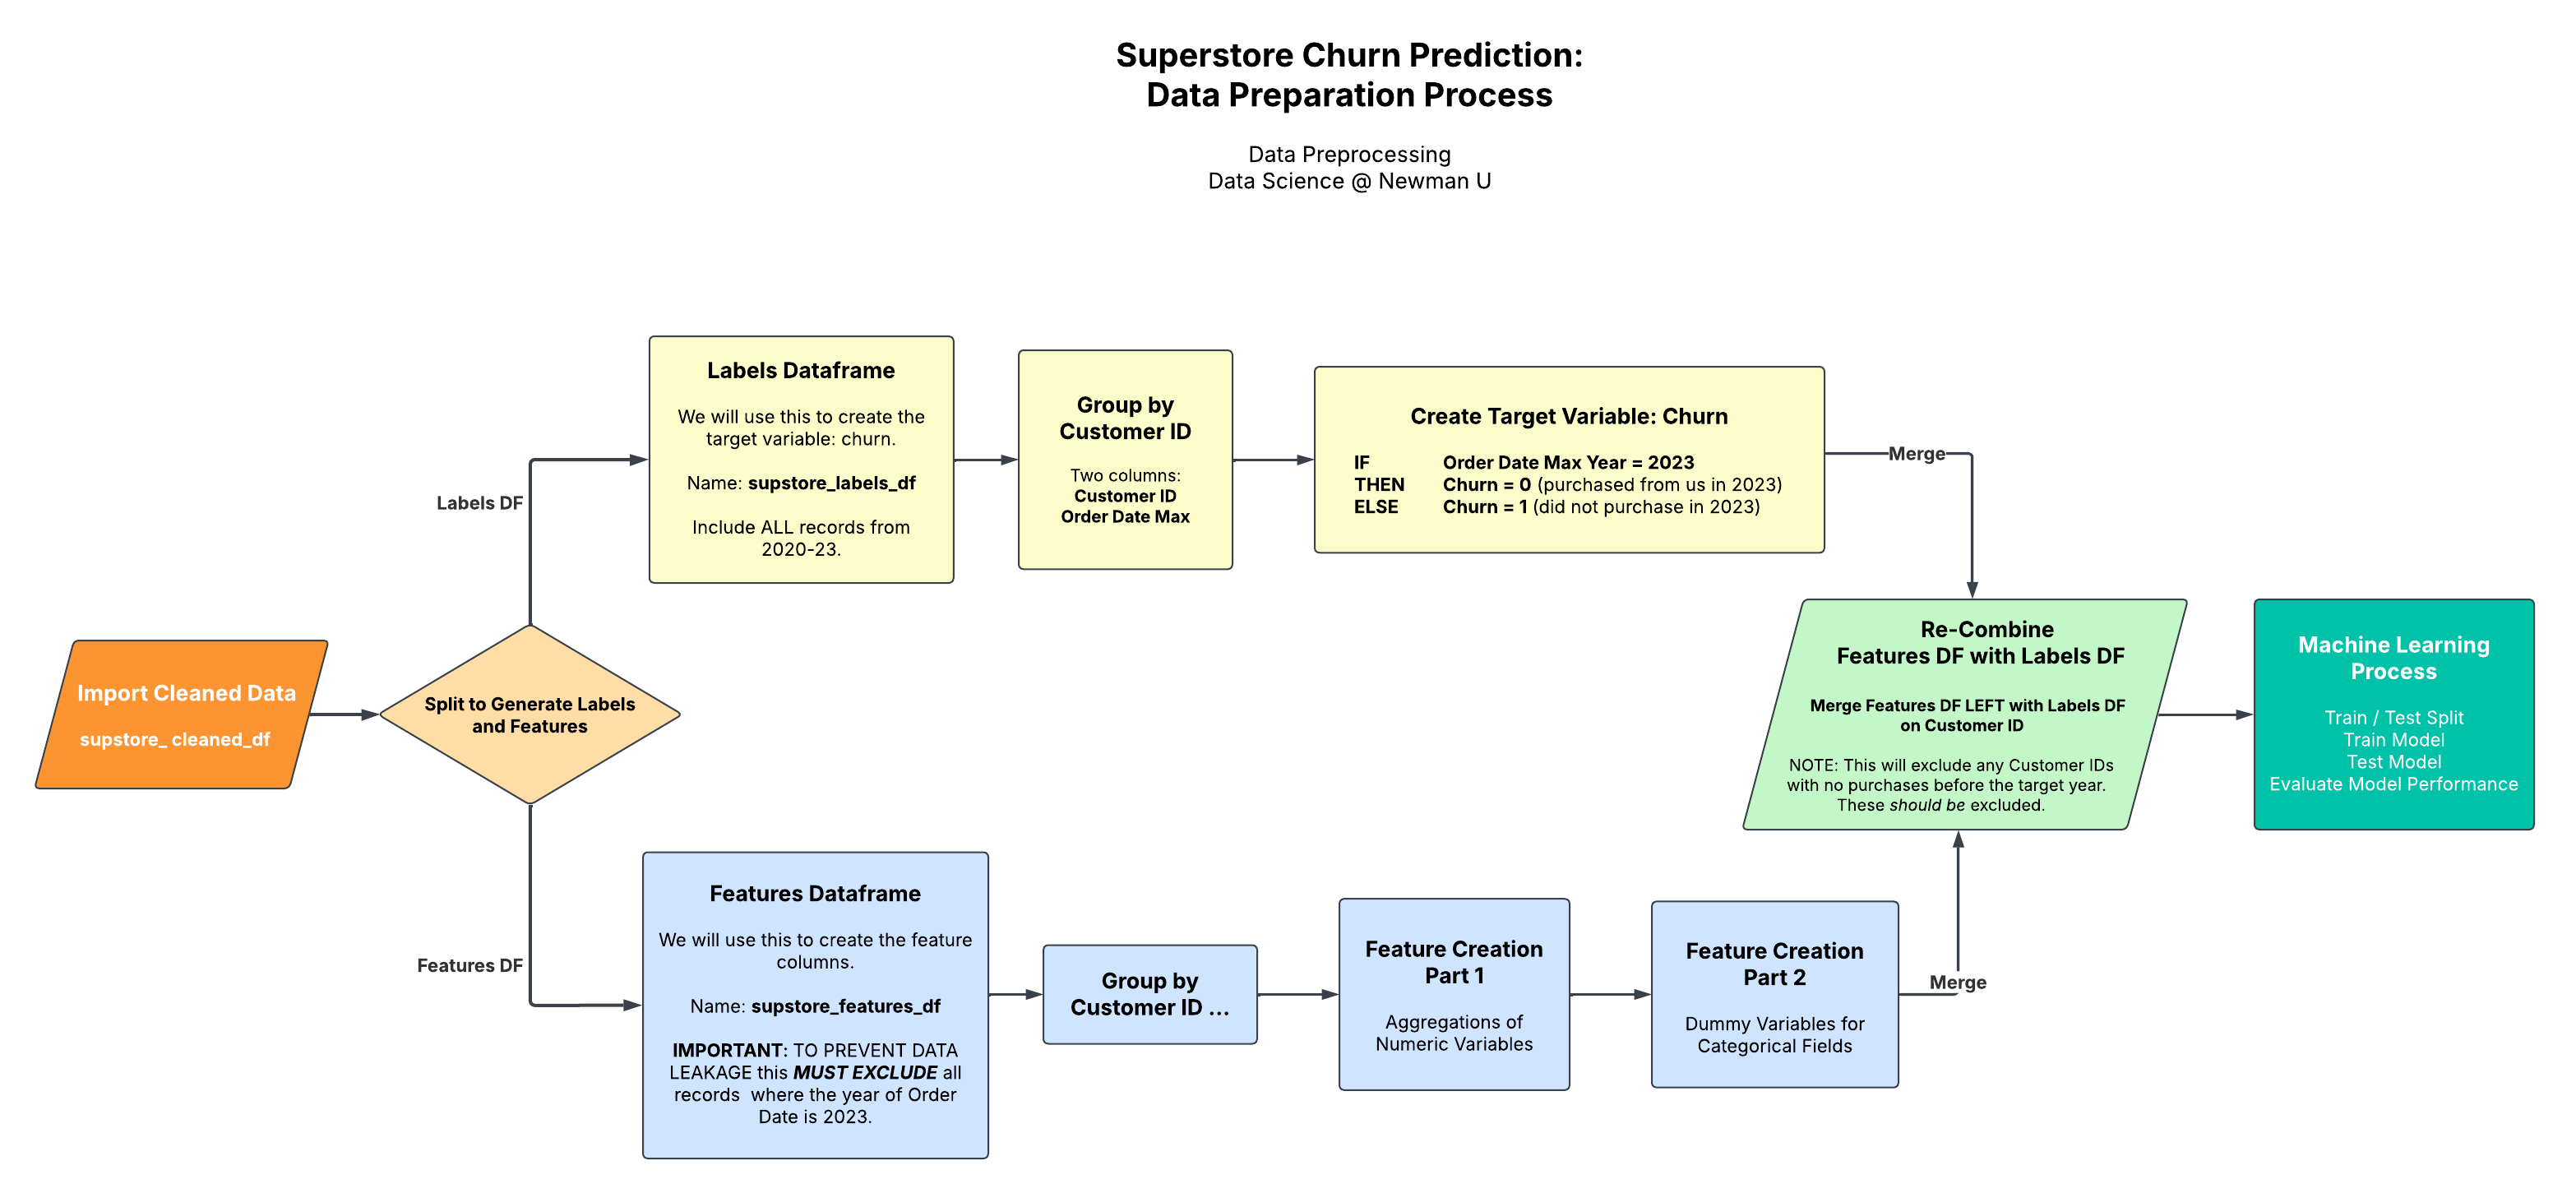

# Import Libraries and Set Notebook Defaults

In [1]:
# Numpy and Pandas
import numpy as np
import pandas as pd

# Matplotlib and Seaborn
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Jupyter Notebook customizations

# Remove scientific notation from descriptive stats
pd.options.display.float_format = '{:,.3f}'.format

# Display all columns of a dataframe
pd.set_option('display.max_columns', None)

# Widen columns
pd.set_option('display.max_colwidth', 150)

In [3]:
# Customize Seaborn Plot Styles

# Adjust to retina quality
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")

# Adjust dpi and font size to support high-pixel-density screens
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook', font_scale = 0.8)

# Display tick marks
sns.set_style('ticks')

# Remove borders
plt.rc('axes.spines', top=False, right=False, left=False, bottom=False)

# Set color palettes for plots
# See Matplotlib named color options here: https://matplotlib.org/stable/gallery/color/named_colors.html
blue = 'deepskyblue' # Use 'skyblue' for a lighter blue
orange = 'orange'
cp1 = [blue, orange]

# cp2 Palette - Reversed binary color order when needed for certain plots
cp2 = [orange, blue]

# cp5 Palette - 5 colors for use with categorical data
turquoise = 'mediumaquamarine'
salmon = 'darksalmon'
tan = 'tan'
gray = 'darkgray'
cp5 = [blue, turquoise, salmon, tan, gray]

# cpd Palette - blue-to-orange diverging palette for correlation heatmaps
cpd = sns.diverging_palette(242, 39, s=100, l=65, n=11)

# Set the default palette
sns.set_palette(cp5)

In [4]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Cleaned Data

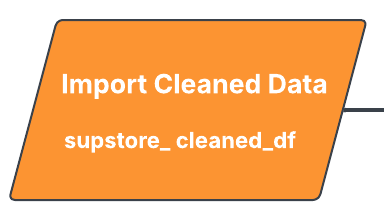

In [5]:
# Read from CSV
# Set appropriate data types

# Set file path
path = '/content/drive/MyDrive/newman_data_preprocessing/Superstore Churn Modeling/data/Global_Superstore_Orders_2020_23.csv'

# Read data
# Set Postal Code datatype to string and fill to 5 digits with leading zeros
superstore_cleaned_df = pd.read_csv(path, dtype={'Postal Code': str})

# Fill postal codes to 5 characters with leading zeros when needed
superstore_cleaned_df['Postal Code'] = superstore_cleaned_df['Postal Code'].str.zfill(5)

# Convert dates to datetime
superstore_cleaned_df['Order Date'] = pd.to_datetime(superstore_cleaned_df['Order Date'])
superstore_cleaned_df['Ship Date'] = pd.to_datetime(superstore_cleaned_df['Ship Date'])

superstore_cleaned_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2012-TB112803-40909,2020-01-01,2020-01-06,Standard Class,TB-112803,Toby Braunhardt,Consumer,NaN,Constantine,Constantine,Algeria,North Africa,Africa,OFF-ST-6261,Office Supplies,Storage,"Tenex Lockers, Blue",979.920,2,0.000,254.736,35.460,Medium
1,22253,IN-2012-JH159857-40909,2020-01-01,2020-01-08,Standard Class,JH-159857,Joseph Holt,Consumer,NaN,Wagga Wagga,New South Wales,Australia,Oceania,Asia Pacific,OFF-SU-3002,Office Supplies,Supplies,"Acme Trimmer, High Speed",288.878,3,0.100,86.486,9.720,Medium
2,48883,HU-2012-AT73557-40909,2020-01-01,2020-01-05,Second Class,AT-73557,Annie Thurman,Consumer,NaN,Budapest,Budapest,Hungary,Eastern Europe,Europe,OFF-ST-6230,Office Supplies,Storage,"Tenex Box, Single Width",158.688,4,0.000,71.136,8.170,High
3,11731,IT-2012-EM14140124-40909,2020-01-01,2020-01-05,Second Class,EM-14140124,Eugene Moren,Home Office,NaN,Stockholm,Stockholm,Sweden,Northern Europe,Europe,OFF-PA-4177,Office Supplies,Paper,"Enermax Note Cards, Premium",107.676,3,0.500,-62.532,4.820,High
4,22255,IN-2012-JH159857-40909,2020-01-01,2020-01-08,Standard Class,JH-159857,Joseph Holt,Consumer,NaN,Wagga Wagga,New South Wales,Australia,Oceania,Asia Pacific,FUR-FU-4075,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",272.808,5,0.100,90.648,4.700,Medium


In [6]:
superstore_cleaned_df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,47594,MO-2015-LP709586-42369,2023-12-31,2024-01-05,Standard Class,LP-709586,Liz Preis,Consumer,NaN,Agadir,Souss-Massa-Draâ,Morocco,North Africa,Africa,OFF-BI-6397,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",9.576,1,0.000,1.008,1.490,Medium
51286,27700,IN-2015-KM1622527-42369,2023-12-31,2024-01-07,Standard Class,KM-1622527,Kalyca Meade,Corporate,NaN,Shantou,Guangdong,China,Eastern Asia,Asia Pacific,OFF-PA-4002,Office Supplies,Paper,"Eaton Note Cards, 8.5 x 11",190.728,3,0.000,60.912,1.410,Medium
51287,8857,MX-2015-CM1219093-42369,2023-12-31,2024-01-02,Second Class,CM-1219093,Charlotte Melton,Consumer,NaN,Managua,Managua,Nicaragua,Central America,LATAM,OFF-LA-4637,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",63.360,3,0.000,29.664,1.350,Medium
51288,2143,MX-2015-JB1604582-42369,2023-12-31,2024-01-04,Standard Class,JB-1604582,Julia Barnett,Home Office,NaN,Reynosa,Tamaulipas,Mexico,Central America,LATAM,OFF-LA-5388,Office Supplies,Labels,"Novimex Legal Exhibit Labels, Adjustable",40.176,3,0.000,1.584,1.324,Medium
51289,6852,MX-2015-TD2099582-42369,2023-12-31,2024-01-06,Standard Class,TD-2099582,Tamara Dahlen,Consumer,NaN,Juárez,Chihuahua,Mexico,Central America,LATAM,OFF-LA-4664,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",17.088,1,0.000,1.344,1.199,Medium


In [7]:
# Get number of rows and columns
superstore_cleaned_df.shape

(51290, 24)

In [8]:
# Dataframe fundamental info
superstore_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   Postal Code     9994 non-null   object        
 9   City            51290 non-null  object        
 10  State           51290 non-null  object        
 11  Country         51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Market          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [9]:
superstore_cleaned_df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,"51,290.000",51290,51290,"51,290.000","51,290.000","51,290.000","51,290.000","51,290.000"
mean,"25,645.500",2022-05-11 21:26:49.155780352,2022-05-15 20:42:42.745174528,591.577,3.477,0.143,68.666,26.479
min,1.000,2020-01-01 00:00:00,2020-01-03 00:00:00,1.066,1.000,0.000,"-15,839.947",1.002
25%,"12,823.250",2021-06-19 00:00:00,2021-06-23 00:00:00,73.821,2.000,0.000,0.000,2.610
50%,"25,645.500",2022-07-08 00:00:00,2022-07-12 00:00:00,204.127,3.000,0.000,22.176,7.790
75%,"38,467.750",2023-05-22 00:00:00,2023-05-26 00:00:00,602.528,5.000,0.200,88.344,24.450
max,"51,290.000",2023-12-31 00:00:00,2024-01-07 00:00:00,"54,332.352",14.000,0.850,"20,159.942",933.570
std,"14,806.292",NaN,NaN,"1,170.157",2.279,0.212,418.418,57.251


In [10]:
superstore_cleaned_df.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,9994,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25728,4,17415,796,3,631,3650,1102,165,23,5,3788,3,17,3788,4
top,CA-2015-SV20365140-42268,Standard Class,SV-203651406,Muhammed Yedwab,Consumer,10035,New York City,California,United States,Western Europe,Asia Pacific,OFF-FA-6129,Office Supplies,Binders,Staples,Medium
freq,14,30775,26,108,26518,263,915,2001,9994,5883,14302,227,31289,6146,227,29433


# Create Labels Dataframe

We will create the first of two dataframes from superstore_cleaned_df:
- superstore_labels_df

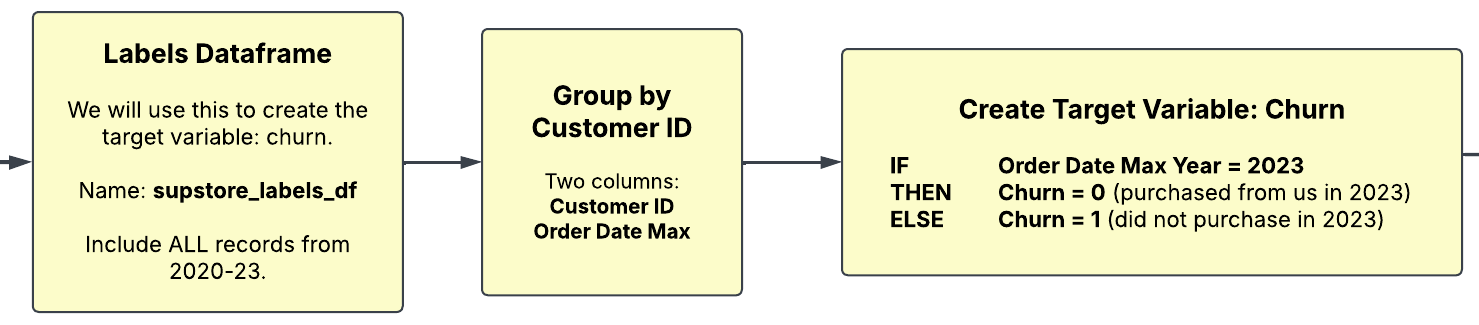

In [11]:
# Create Labels Dataframe
# Include all records
# Three columns: CustomerID (index), Order Date Min, and Order Date Max

# Group by Customer and aggregate the Min and Max Order Date
superstore_labels_df = superstore_cleaned_df.groupby('Customer ID')['Order Date'].agg(['min', 'max'])

# Rename columns for clarity
superstore_labels_df = superstore_labels_df.rename(columns={'min': 'Min Order Date', 'max': 'Max Order Date'})

# Preview results
superstore_labels_df.sample(12)

,Min Order Date,Max Order Date
Customer ID,,
PV-189851402,2020-07-11,2022-02-22
CM-1216082,2023-07-19,2023-07-19
AR-1082528,2021-08-09,2021-08-09
CD-1192031,2023-04-25,2023-04-25
BN-115151406,2022-05-20,2023-09-02
EH-141855,2023-10-25,2023-10-25
SJ-2012578,2023-08-14,2023-08-14
BE-1141098,2021-12-04,2021-12-04
BD-117701406,2022-03-11,2023-02-07


In [12]:
superstore_labels_df.sample(50)

,Min Order Date,Max Order Date
Customer ID,,
DH-130751402,2022-06-25,2022-06-25
VB-217451406,2022-10-29,2022-10-29
PB-191501408,2020-12-11,2020-12-11
NR-185501404,2020-09-16,2020-09-16
DJ-134201404,2020-12-07,2021-10-10
JL-151751404,2020-12-30,2023-12-25
DK-1298558,2020-03-17,2022-08-12
AS-285147,2020-03-20,2020-03-20
PF-191657,2020-03-21,2023-06-13


**Eliminate all Customers who did not make a purchase before 2023.**

- We are only interested in customers who made a first purchase prior to 2023.

- Non-churners purchased before 2023 and then made another in 2023.

- Churners also purchased before 2023 but then did not return in 2023.

So: Eliminate all customers from our list who made no purchases before 2023.

In [13]:
# Remove all customers whose Min Order Date year is 2023.

superstore_labels_df = superstore_labels_df[superstore_labels_df['Min Order Date'].dt.year < 2023]

superstore_labels_df.sample(25)


,Min Order Date,Max Order Date
Customer ID,,
AA-104801402,2022-07-18,2022-08-27
OT-87303,2020-12-19,2020-12-19
MW-1823558,2020-06-08,2023-06-02
SW-2035091,2022-12-16,2022-12-16
RW-1954097,2021-07-21,2021-07-21
BG-1103514,2021-04-03,2021-04-03
Dl-3600134,2021-06-01,2021-06-01
SP-2054558,2022-12-30,2023-11-05
RA-19285120,2020-12-13,2021-12-24


In [14]:
# View Labels Dataframe Info
superstore_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12780 entries, AA-10315102 to ZD-2192596
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Min Order Date  12780 non-null  datetime64[ns]
 1   Max Order Date  12780 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 299.5+ KB


In [15]:
# Create Churn Target Variable
# If the Year of Max Order Date == 2023
# Then Churn = 0
# Else Churn = 1

superstore_labels_df['Churn'] = np.where(superstore_labels_df['Max Order Date'].dt.year == 2023, 0, 1)

superstore_labels_df.sample(25)


,Min Order Date,Max Order Date,Churn
Customer ID,,,
TG-21640139,2022-11-21,2023-06-02,0
MC-1759045,2021-12-05,2021-12-05,1
RD-972095,2020-02-17,2020-02-17,1
KW-1657055,2020-10-09,2020-10-09,1
BD-1156018,2021-10-25,2021-10-25,1
CA-11965139,2021-01-22,2021-01-22,1
MS-175308,2021-10-17,2021-10-17,1
JD-15790144,2021-02-14,2021-02-14,1
EN-378038,2022-12-25,2022-12-25,1


In [16]:
# View a bigger sample
superstore_labels_df.sample(25)

,Min Order Date,Max Order Date,Churn
Customer ID,,,
MW-8220134,2021-05-04,2021-05-04,1
BG-1169527,2021-03-20,2021-03-20,1
HH-1501018,2021-08-22,2022-12-26,1
SE-2011027,2022-01-28,2022-01-28,1
EH-1376545,2020-01-17,2020-01-17,1
MT-18070102,2022-12-19,2022-12-19,1
HG-1502518,2020-06-08,2023-06-09,0
JC-161051402,2020-11-17,2020-11-17,1
NF-859583,2022-08-02,2022-08-02,1


In [17]:
# Get info on our Labels dataframe
superstore_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12780 entries, AA-10315102 to ZD-2192596
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Min Order Date  12780 non-null  datetime64[ns]
 1   Max Order Date  12780 non-null  datetime64[ns]
 2   Churn           12780 non-null  int64         
dtypes: datetime64[ns](2), int64(1)
memory usage: 915.4+ KB


In [18]:
# Compare number of Churn = 1 versus Churn = 0
superstore_labels_df['Churn'].value_counts()

,count
Churn,
1,9791
0,2989


# Create Features Dataframe

The better features we create, the more effectively our machine learning algorithms can understand the data and generate better predictions.

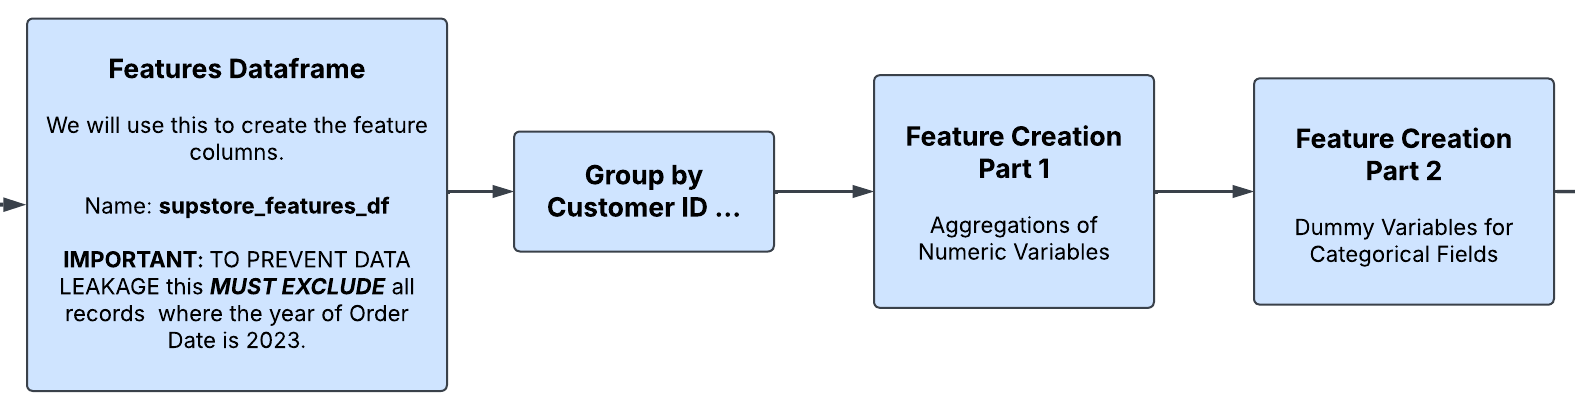

In [19]:
# Create Features Dataframe
# Eliminate all records from 2023 to ensure there is no data leakage
superstore_features_df = superstore_cleaned_df[superstore_cleaned_df['Order Date'] < '2023-01-01']
superstore_features_df.sample(25)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
12219,11702,ES-2013-GA1472545-41429,2021-06-04,2021-06-08,Standard Class,GA-1472545,Guy Armstrong,Consumer,NaN,Tours,Centre-Val de Loire,France,Western Europe,Europe,FUR-CH-5370,Furniture,Chairs,"Novimex Chairmat, Adjustable",635.364,5,0.100,197.604,27.670,Medium
16701,31406,CA-2013-PA19060140-41562,2021-10-15,2021-10-20,Standard Class,PA-190601402,Pete Armstrong,Home Office,60462,Orland Park,Illinois,United States,Central US,USCA,TEC-AC-5146,Technology,Accessories,Logitech Gaming G510s - Keyboard,815.904,5,0.200,163.181,13.560,Medium
17327,8597,MX-2013-CL11890100-41580,2021-11-02,2021-11-07,Standard Class,CL-11890100,Carl Ludwig,Consumer,NaN,San Lorenzo,Central,Paraguay,South America,LATAM,OFF-FA-5469,Office Supplies,Fasteners,"OIC Paper Clips, Bulk Pack",46.176,2,0.000,5.952,1.497,Medium
20808,21515,ID-2014-SH2039527-41677,2022-02-07,2022-02-14,Standard Class,SH-2039527,Shahid Hopkins,Consumer,NaN,Huainan,Anhui,China,Eastern Asia,Asia Pacific,TEC-AC-5864,Technology,Accessories,"SanDisk Keyboard, Bluetooth","1,173.312",6,0.000,281.232,41.800,Medium
4450,49224,IR-2012-JK562560-41139,2020-08-18,2020-08-23,Standard Class,JK-562560,Jim Karlsson,Consumer,NaN,Ardabil,Ardabil,Iran,Southern Asia,Asia Pacific,OFF-SU-4125,Office Supplies,Supplies,"Elite Ruler, Serrated",25.200,1,0.000,4.536,1.490,Medium
27344,38165,US-2014-SC20230140-41873,2022-08-22,2022-08-29,Standard Class,SC-202301404,Scot Coram,Corporate,90004,Los Angeles,California,United States,Western US,USCA,FUR-TA-3561,Furniture,Tables,Bretford CR8500 Series Meeting Room Furniture,"6,928.934",9,0.200,433.058,268.100,Low
28801,5234,MX-2014-FH1436593-41901,2022-09-19,2022-09-24,Second Class,FH-1436593,Fred Hopkins,Corporate,NaN,León,León,Nicaragua,Central America,LATAM,OFF-SU-4978,Office Supplies,Supplies,"Kleencut Letter Opener, Easy Grip",91.776,2,0.000,23.808,1.952,Medium
15950,17487,ES-2013-DG1330064-41541,2021-09-24,2021-09-28,Second Class,DG-1330064,Deirdre Greer,Corporate,NaN,Milan,Lombardy,Italy,Southern Europe,Europe,TEC-MA-6139,Technology,Machines,"StarTech Card Printer, Wireless",706.320,3,0.400,-153.144,6.250,Medium
15435,40159,CA-2013-SN20560140-41528,2021-09-11,2021-09-18,Standard Class,SN-205601406,Skye Norling,Home Office,07501,Paterson,New Jersey,United States,Eastern US,USCA,OFF-BI-4831,Office Supplies,Binders,Ibico Laser Imprintable Binding System Covers,503.040,4,0.000,231.398,10.410,Medium
32723,8470,MX-2014-BN1147051-41984,2022-12-11,2022-12-17,Standard Class,BN-1147051,Brad Norvell,Corporate,NaN,Chimaltenango,Chimaltenango,Guatemala,Central America,LATAM,OFF-BI-2915,Office Supplies,Binders,"Acco Hole Reinforcements, Recycled",101.088,9,0.000,47.088,7.480,Low


In [20]:
# Get features dataframe info
superstore_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33759 entries, 0 to 33758
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          33759 non-null  int64         
 1   Order ID        33759 non-null  object        
 2   Order Date      33759 non-null  datetime64[ns]
 3   Ship Date       33759 non-null  datetime64[ns]
 4   Ship Mode       33759 non-null  object        
 5   Customer ID     33759 non-null  object        
 6   Customer Name   33759 non-null  object        
 7   Segment         33759 non-null  object        
 8   Postal Code     6675 non-null   object        
 9   City            33759 non-null  object        
 10  State           33759 non-null  object        
 11  Country         33759 non-null  object        
 12  Region          33759 non-null  object        
 13  Market          33759 non-null  object        
 14  Product ID      33759 non-null  object        
 15  Categor

In [21]:
# Double check to ensure we include NO RECORDS with Order Date in 2023
# Get max order date of Features Dataframe
superstore_features_df['Order Date'].max()

Timestamp('2022-12-31 00:00:00')

In [22]:
# TRIPLE check to ensure we include NO RECORDS with Order Date in 2023
# Sort Features Dataframe from Latest Order Date and viewing head()
superstore_features_df.sort_values(by='Order Date', ascending=False).head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
33758,49701,IZ-2014-DM301561-42004,2022-12-31,2023-01-02,Second Class,DM-301561,Darrin Martin,Consumer,NaN,Basra,Al Basrah,Iraq,Western Asia,Asia Pacific,OFF-BI-6380,Office Supplies,Binders,"Wilson Jones Binder, Economy",31.248,1,0.000,9.648,1.140,Medium
33714,39963,CA-2014-CJ11875140-42004,2022-12-31,2023-01-03,First Class,CJ-118751406,Carl Jackson,Corporate,19140,Philadelphia,Pennsylvania,United States,Eastern US,USCA,OFF-AR-5286,Office Supplies,Art,Newell 31,39.648,5,0.200,3.965,1.420,High
33727,5255,MX-2014-AH1046593-42004,2022-12-31,2023-01-01,First Class,AH-1046593,Amy Hunt,Consumer,NaN,León,León,Nicaragua,Central America,LATAM,OFF-PA-3995,Office Supplies,Paper,"Eaton Memo Slips, Multicolor",121.200,5,0.000,12.000,11.382,High
33726,40579,CA-2014-EH14185140-42004,2022-12-31,2023-01-05,Standard Class,EH-141851408,Evan Henry,Consumer,33407,West Palm Beach,Florida,United States,Southern US,USCA,OFF-PA-4139,Office Supplies,Paper,Embossed Ink Jet Note Cards,173.338,4,0.200,60.668,2.860,Medium
33725,28024,IN-2014-BD11635144-42004,2022-12-31,2023-01-04,Standard Class,BD-11635144,Brian Derr,Consumer,NaN,Hanoi,Thủ Dô Hà Nội,Vietnam,Southeastern Asia,Asia Pacific,FUR-BO-3615,Furniture,Bookcases,"Bush 3-Shelf Cabinet, Metal",431.918,2,0.370,47.870,12.300,Medium


**Create Features using groupby and aggregation**

In [23]:
# This cell is for Module 2.2 it calculates all of the new features

# Average Quantity
avg_quantity = (
    superstore_features_df.groupby('Customer ID')['Quantity']
    .mean()
    .rename('avg_quantity')
)

# Produces: pct_furniture, pct_office_supplies, pct_technology with a percent
# weighted by the amount of sales for each category
category_dummies = (
    superstore_features_df.groupby(['Customer ID', 'Category'])['Sales']
    .sum()
    .groupby('Customer ID')
    .transform(lambda x: x / x.sum())
    .unstack(fill_value=0)
    .rename(columns=lambda c: f'pct_{c.lower().replace(" ", "_")}')
)

# Create dummy variables for market
market_dummies = (
    pd.get_dummies(
        superstore_features_df.groupby('Customer ID')['Market'].first(),
        prefix='market',
        dtype=int
    )
)

# Negative profit rate - percentage of orders with negative profit
# May indicate dissatisfaction, returns, or problem transactions
neg_profit_rate = (
    superstore_features_df.groupby('Customer ID')['Profit']
    .apply(lambda x: (x < 0).mean())
    .rename('neg_profit_rate')
)

# Profit Margin - ratio of profit to sales per customer
# Captures customer profitability independent of volume
profit_margin = (
    superstore_features_df.groupby('Customer ID')
    .apply(lambda g: g['Profit'].sum() / g['Sales'].sum() if g['Sales'].sum() != 0 else 0, include_groups=False)
    .rename('profit_margin')
)


In [24]:
# This cell is for Module 2.1 it calculates all of the new features

# Define a reference date (the latest order date in the historical data)
reference_date = superstore_features_df['Order Date'].max()

# Recency - days since last order
recency = (
    superstore_features_df.groupby('Customer ID')['Order Date']
    .max()
    .apply(lambda x: (reference_date - x).days)
    .rename('recency_days')
)

# Tenure - days from first order to reference date
# Longer-tenured customers who stop buying are a different churn signal
# than someone who placed one order recently
tenure = (
    superstore_features_df.groupby('Customer ID')['Order Date']
    .min()
    .apply(lambda x: (reference_date - x).days)
    .rename('tenure_days')
)

# Frequency - unique order count per customer
frequency = (
    superstore_features_df.groupby('Customer ID')['Order ID']
    .nunique()
    .rename('order_count')
)

# Gap Trend - compares recent vs historical inter-order gaps
# Positive = gaps widening (customer drifting away)
# Negative = gaps shrinking (customer engaging more)
def gap_trend_func(group):
    dates = group.sort_values()
    gaps = dates.diff().dt.days.dropna()
    if len(gaps) < 4:
        return np.nan
    midpoint = len(gaps) // 2
    early_avg = gaps.iloc[:midpoint].mean()
    late_avg = gaps.iloc[midpoint:].mean()
    return late_avg - early_avg

gap_trend = (
    superstore_features_df.groupby('Customer ID')['Order Date']
    .apply(gap_trend_func, include_groups=False)
    .rename('gap_trend_days')
)

# Report gap_trend coverage before filling NaNs
gap_computed = gap_trend.notna().sum()
gap_total = len(gap_trend)
print(f'Gap trend computed for {gap_computed} of {gap_total} customers ({gap_computed/gap_total*100:.1f}%)')
print(f'Remaining {gap_total - gap_computed} customers have < 4 orders (filled with 0)')

gap_trend = gap_trend.fillna(0)

# AVG Discount
avg_discount = (
    superstore_features_df.groupby('Customer ID')['Discount']
    .mean()
    .rename('avg_discount')
)

# AVG Days to Ship
superstore_features_df = superstore_features_df.copy()
superstore_features_df['days_to_ship'] = (superstore_features_df['Ship Date'] - superstore_features_df['Order Date']).dt.days

avg_ship_time = (
    superstore_features_df.groupby('Customer ID')['days_to_ship']
    .mean()
    .rename('avg_days_to_ship')
)

# Product Breadth - number of distinct categories purchased (out of 3)
product_breadth = (
    superstore_features_df.groupby('Customer ID')['Category']
    .nunique()
    .rename('category_breadth')
)

# Ship Cost Ratio - Shipping Cost / Sales
ship_cost_ratio = (
    superstore_features_df.groupby('Customer ID')
    .apply(lambda g: g['Shipping Cost'].sum() / g['Sales'].sum() if g['Sales'].sum() != 0 else 0, include_groups=False)
    .rename('ship_cost_ratio')
)


Gap trend computed for 1901 of 12780 customers (14.9%)
Remaining 10879 customers have < 4 orders (filled with 0)


In [25]:
# Groupby Customer ID for base aggregations
# Keep only mean Sales and mean Profit (dropped sums to reduce multicollinearity)
# Dropped Row ID count (redundant with order_count from frequency calculation)

superstore_features_df = superstore_features_df.groupby('Customer ID').agg(
    {'Sales': 'mean', 'Profit': 'mean'}
)

# Rename columns for clarity
superstore_features_df.columns = ['Sales_mean', 'Profit_mean']


In [26]:
# Consolidate all features into one features dataframe
all_new_features = pd.concat([
    recency,
    tenure,
    frequency,
    gap_trend,
    avg_discount,
    avg_ship_time,
    ship_cost_ratio,
    avg_quantity,
    product_breadth,
    category_dummies,
    market_dummies,
    neg_profit_rate,
    profit_margin
], axis=1)

# Merge all new features at once
superstore_features_df = superstore_features_df.merge(all_new_features, on='Customer ID')

print(f'Feature set: {superstore_features_df.shape[1]} features for {superstore_features_df.shape[0]} customers')
superstore_features_df.sample(20)


Feature set: 21 features for 12780 customers


,Sales_mean,Profit_mean,recency_days,tenure_days,order_count,gap_trend_days,avg_discount,avg_days_to_ship,ship_cost_ratio,avg_quantity,category_breadth,pct_furniture,pct_office_supplies,pct_technology,market_Africa,market_Asia Pacific,market_Europe,market_LATAM,market_USCA,neg_profit_rate,profit_margin
Customer ID,,,,,,,,,,,,,,,,,,,,,
TB-212801408,230.323,23.032,761,761,1,0.000,0.200,6.000,0.020,4.000,1,0.000,0.000,1.000,0,0,0,0,1,0.000,0.100
AT-1073518,391.786,-0.029,372,432,2,-30.000,0.040,5.200,0.030,3.200,2,0.619,0.381,0.000,0,0,0,1,0,0.200,-0.000
GH-144108,129.600,18.144,276,276,1,0.000,0.000,2.000,0.019,6.000,1,0.000,1.000,0.000,0,0,1,0,0,0.000,0.140
HG-1502593,95.760,23.376,472,472,1,0.000,0.000,1.000,0.053,3.000,1,0.000,1.000,0.000,0,0,0,1,0,0.000,0.244
JK-1609093,274.221,56.937,249,481,2,0.000,0.001,5.250,0.040,3.750,2,0.000,0.164,0.836,0,0,0,1,0,0.000,0.208
RD-1981028,615.662,115.886,17,17,1,0.000,0.002,4.000,0.081,2.000,1,0.000,0.000,1.000,0,0,0,1,0,0.000,0.188
MO-1795082,227.664,86.400,453,453,1,0.000,0.000,5.000,0.027,3.000,1,0.000,1.000,0.000,0,0,0,1,0,0.000,0.380
CS-1195036,660.096,-119.232,859,929,2,0.000,0.200,6.000,0.011,4.667,2,0.895,0.105,0.000,0,0,0,1,0,0.333,-0.181
AA-1064511,109.764,12.960,101,101,1,0.000,0.000,5.000,0.031,1.500,2,0.000,0.539,0.461,0,1,0,0,0,0.000,0.118


In [27]:
# Get info on new dataframe
superstore_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12780 entries, AA-10315102 to ZD-2192596
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_mean           12780 non-null  float64
 1   Profit_mean          12780 non-null  float64
 2   recency_days         12780 non-null  int64  
 3   tenure_days          12780 non-null  int64  
 4   order_count          12780 non-null  int64  
 5   gap_trend_days       12780 non-null  float64
 6   avg_discount         12780 non-null  float64
 7   avg_days_to_ship     12780 non-null  float64
 8   ship_cost_ratio      12780 non-null  float64
 9   avg_quantity         12780 non-null  float64
 10  category_breadth     12780 non-null  int64  
 11  pct_furniture        12780 non-null  float64
 12  pct_office_supplies  12780 non-null  float64
 13  pct_technology       12780 non-null  float64
 14  market_Africa        12780 non-null  int64  
 15  market_Asia Pacific  12780

# Merge Features Dataframe and Labels Dataframe


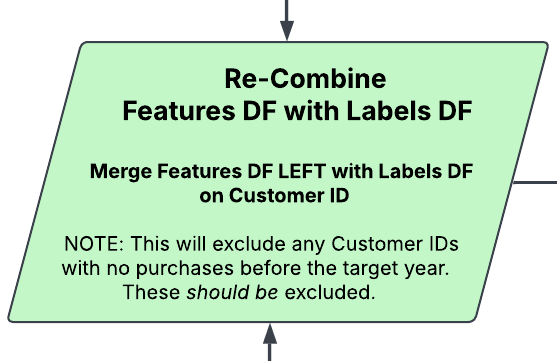

In [28]:
# Revisit Labels Dataframe
superstore_labels_df.head(12)

,Min Order Date,Max Order Date,Churn
Customer ID,,,
AA-10315102,2020-07-03,2023-01-07,0
AA-10315120,2021-05-16,2021-05-16,1
AA-10315139,2022-09-19,2023-08-04,0
AA-103151402,2022-03-04,2023-06-30,0
AA-103151404,2020-03-30,2021-10-04,1
AA-103151406,2020-09-14,2020-09-14,1
AA-1031548,2022-08-07,2022-08-07,1
AA-1031558,2022-12-31,2023-12-23,0
AA-1031582,2020-11-23,2022-02-05,1


In [29]:
# Drop other fields from Labels Dataframe
superstore_labels_df = superstore_labels_df.drop(columns=['Min Order Date','Max Order Date'])
superstore_labels_df.head(12)

,Churn
Customer ID,
AA-10315102,0
AA-10315120,1
AA-10315139,0
AA-103151402,0
AA-103151404,1
AA-103151406,1
AA-1031548,1
AA-1031558,0
AA-1031582,1


In [30]:
# Merge Features Dataframe and Labels Dataframe
# Use Customer ID as the common key
superstore_churn_df = superstore_features_df.merge(superstore_labels_df, on='Customer ID')
superstore_churn_df.sample(20)

,Sales_mean,Profit_mean,recency_days,tenure_days,order_count,gap_trend_days,avg_discount,avg_days_to_ship,ship_cost_ratio,avg_quantity,category_breadth,pct_furniture,pct_office_supplies,pct_technology,market_Africa,market_Asia Pacific,market_Europe,market_LATAM,market_USCA,neg_profit_rate,profit_margin,Churn
Customer ID,,,,,,,,,,,,,,,,,,,,,,
DB-336022,486.270,83.970,69,69,1,0.000,0.000,4.000,0.026,1.250,3,0.050,0.292,0.658,1,0,0,0,0,0.000,0.173,1
AG-1052548,"1,229.429",361.805,314,648,2,0.000,0.033,4.333,0.051,4.000,2,0.000,0.021,0.979,0,0,1,0,0,0.000,0.294,1
CL-270029,"1,402.020",152.280,4,4,1,0.000,0.000,5.000,0.042,4.500,1,0.000,1.000,0.000,1,0,0,0,0,0.000,0.109,1
SS-2087545,32.832,6.768,508,508,1,0.000,0.000,4.000,0.038,2.000,1,0.000,1.000,0.000,0,0,1,0,0,0.000,0.206,1
HM-1498059,"1,728.076",-353.516,433,433,1,0.000,0.320,6.000,0.031,4.500,1,0.000,1.000,0.000,0,1,0,0,0,1.000,-0.205,0
JG-511586,328.536,51.312,133,448,2,0.000,0.000,2.667,0.041,4.333,2,0.000,0.700,0.300,1,0,0,0,0,0.000,0.156,1
LC-696086,357.667,133.200,344,344,1,0.000,0.000,5.000,0.025,1.200,2,0.000,0.110,0.890,1,0,0,0,0,0.000,0.372,1
MZ-1733551,598.896,191.280,406,406,1,0.000,0.000,4.000,0.036,2.500,1,1.000,0.000,0.000,0,0,0,1,0,0.000,0.319,1
SC-2072558,40.896,17.568,886,886,1,0.000,0.000,5.000,0.050,1.000,1,0.000,1.000,0.000,0,1,0,0,0,0.000,0.430,1


In [31]:
# Get an overview of our combined dataframe
superstore_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12780 entries, AA-10315102 to ZD-2192596
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_mean           12780 non-null  float64
 1   Profit_mean          12780 non-null  float64
 2   recency_days         12780 non-null  int64  
 3   tenure_days          12780 non-null  int64  
 4   order_count          12780 non-null  int64  
 5   gap_trend_days       12780 non-null  float64
 6   avg_discount         12780 non-null  float64
 7   avg_days_to_ship     12780 non-null  float64
 8   ship_cost_ratio      12780 non-null  float64
 9   avg_quantity         12780 non-null  float64
 10  category_breadth     12780 non-null  int64  
 11  pct_furniture        12780 non-null  float64
 12  pct_office_supplies  12780 non-null  float64
 13  pct_technology       12780 non-null  float64
 14  market_Africa        12780 non-null  int64  
 15  market_Asia Pacific  12780

In [32]:
# Get numbers of churn vs non-churners
superstore_churn_df['Churn'].value_counts()

,count
Churn,
1,9791
0,2989


# Machine Learning

We will check the quality of our feature engineering by creating predictions using an efficient and effective machine learning model:

The Random Forest Classifier from Scikit Learn

In [33]:
# Take our prepared dataframe and create X as the features set and y as the labels
X = superstore_churn_df.drop(columns=['Churn'])
y = superstore_churn_df['Churn']

In [34]:
# Preview the features we'll use for machine learning
X.head(12)

,Sales_mean,Profit_mean,recency_days,tenure_days,order_count,gap_trend_days,avg_discount,avg_days_to_ship,ship_cost_ratio,avg_quantity,category_breadth,pct_furniture,pct_office_supplies,pct_technology,market_Africa,market_Asia Pacific,market_Europe,market_LATAM,market_USCA,neg_profit_rate,profit_margin
Customer ID,,,,,,,,,,,,,,,,,,,,,
AA-10315102,242.837,-106.939,911,911,1,0.000,0.450,3.000,0.047,5.750,2,0.000,0.928,0.072,0,1,0,0,0,1.000,-0.440
AA-10315120,"6,512.184",65.016,594,594,1,0.000,0.000,5.000,0.026,7.000,1,1.000,0.000,0.000,0,0,1,0,0,0.000,0.010
AA-10315139,210.348,55.566,34,103,2,0.000,0.000,2.000,0.109,2.000,2,0.000,0.545,0.455,0,0,1,0,0,0.000,0.264
AA-103151402,"2,643.643",-448.261,302,302,1,0.000,0.200,5.000,0.027,3.500,2,0.000,0.892,0.108,0,0,0,0,1,0.250,-0.170
AA-103151404,602.806,219.546,453,1006,2,0.000,0.067,4.333,0.035,2.000,1,0.000,1.000,0.000,0,0,0,0,1,0.000,0.364
AA-103151406,35.400,15.939,838,838,1,0.000,0.000,5.000,0.047,2.500,2,0.494,0.506,0.000,0,0,0,0,1,0.000,0.450
AA-1031548,163.555,54.403,146,146,1,0.000,0.100,5.000,0.033,4.000,1,0.000,1.000,0.000,0,0,1,0,0,0.000,0.333
AA-1031558,"1,198.656",431.424,0,0,1,0.000,0.000,6.000,0.026,4.000,1,1.000,0.000,0.000,0,1,0,0,0,0.000,0.360
AA-1031582,303.754,109.901,329,768,2,219.500,0.000,2.800,0.040,4.200,2,0.000,0.464,0.536,0,0,0,1,0,0.000,0.362


In [35]:
# Preview the labels we'll use for machine learning
y.head(12)

,Churn
Customer ID,
AA-10315102,0
AA-10315120,1
AA-10315139,0
AA-103151402,0
AA-103151404,1
AA-103151406,1
AA-1031548,1
AA-1031558,0
AA-1031582,1


In [36]:
# Import libraries and packages for prediction and evaluation

# For creating train/test splits
from sklearn.model_selection import train_test_split

# For the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# For evaluating a model's predictive performance
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, confusion_matrix


In [37]:
# Create a train / test split, with 30% of the data for test.

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# See the shape of each split compared to the total records: the number and proportion of train and test features and their labels
print(f'Total Records: {len(y)}')
print(f'Train Split: {X_train.shape[0]} Records, {len(y_train)} Labels = {round(len(y_train)/len(y), 4) * 100}%')
print(f'Test Split: {X_test.shape[0]} Records, {len(y_test)} Labels = {round(len(y_test)/len(y), 4) * 100}%')

# Preview the training data
X_train.head()

Total Records: 12780
Train Split: 8946 Records, 8946 Labels = 70.0%
Test Split: 3834 Records, 3834 Labels = 30.0%


,Sales_mean,Profit_mean,recency_days,tenure_days,order_count,gap_trend_days,avg_discount,avg_days_to_ship,ship_cost_ratio,avg_quantity,category_breadth,pct_furniture,pct_office_supplies,pct_technology,market_Africa,market_Asia Pacific,market_Europe,market_LATAM,market_USCA,neg_profit_rate,profit_margin
Customer ID,,,,,,,,,,,,,,,,,,,,,
LO-171701408,211.956,19.668,694,694,1,0.000,0.000,2.000,0.070,4.000,1,0.000,1.000,0.000,0,0,0,0,1,0.000,0.093
SB-1018586,378.486,114.930,36,97,2,0.000,0.000,4.250,0.033,2.500,2,0.765,0.235,0.000,1,0,0,0,0,0.000,0.304
MC-7575137,32.112,12.168,680,680,1,0.000,0.000,4.000,0.056,1.000,1,0.000,1.000,0.000,0,0,1,0,0,0.000,0.379
JF-1519058,612.518,83.376,60,104,2,22.000,0.000,5.200,0.031,3.600,3,0.124,0.054,0.822,0,1,0,0,0,0.000,0.136
AC-42022,130.896,13.728,931,931,1,0.000,0.000,3.000,0.048,1.000,2,0.000,0.164,0.836,1,0,0,0,0,0.000,0.105


In [38]:
# Predict churn using the Random Forest classification model from scikit learn

# Set Random Forest classifier as the algorithm for this prediction
algorithm = RandomForestClassifier(random_state=42)

# Train a prediction model by fitting the algorithm to the training set
model = algorithm.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

print('Predictions Complete\n')

# Dataframe of predicted churn probabilities and churn predictions (0 or 1) per customer
results_df = X_test.copy()
results_df['churn'] = y_test
results_df['predicted_probability'] = model.predict_proba(X_test)[:, 1]
results_df['prediction'] = y_pred

results_df.sample(30)

Predictions Complete



,Sales_mean,Profit_mean,recency_days,tenure_days,order_count,gap_trend_days,avg_discount,avg_days_to_ship,ship_cost_ratio,avg_quantity,category_breadth,pct_furniture,pct_office_supplies,pct_technology,market_Africa,market_Asia Pacific,market_Europe,market_LATAM,market_USCA,neg_profit_rate,profit_margin,churn,predicted_probability,prediction
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,
MM-1828082,934.752,55.776,944,944,1,0.000,0.000,4.000,0.043,7.000,1,0.000,0.000,1.000,0,0,0,1,0,0.000,0.060,1,0.910,1
CJ-1875103,587.952,152.784,260,260,1,0.000,0.000,4.000,0.029,2.000,1,0.000,0.000,1.000,0,0,1,0,0,0.000,0.260,1,0.910,1
TC-2129593,"1,123.264",180.384,63,252,2,0.000,0.000,6.333,0.020,3.333,3,0.069,0.022,0.908,0,0,0,1,0,0.000,0.161,1,0.740,1
SM-2090582,357.840,160.992,8,8,1,0.000,0.000,4.000,0.040,3.000,1,0.000,0.000,1.000,0,0,0,1,0,0.000,0.450,1,0.440,0
PB-1915055,245.214,-40.114,847,921,2,0.000,0.401,4.333,0.060,4.333,3,0.023,0.205,0.772,0,0,0,1,0,1.000,-0.164,1,0.810,1
AD-1018048,94.284,21.996,346,346,1,0.000,0.100,5.000,0.060,1.000,1,1.000,0.000,0.000,0,0,1,0,0,0.000,0.233,1,0.680,1
VG-218051408,26.304,7.102,232,232,1,0.000,0.000,4.000,0.076,4.000,1,0.000,1.000,0.000,0,0,0,0,1,0.000,0.270,1,0.550,1
SN-207101408,489.712,214.786,229,229,1,0.000,0.000,5.000,0.061,5.000,1,0.000,1.000,0.000,0,0,0,0,1,0.000,0.439,1,0.770,1
RF-1934566,844.200,143.136,1036,1036,1,0.000,0.000,4.000,0.019,7.000,1,1.000,0.000,0.000,0,1,0,0,0,0.000,0.170,1,0.730,1


# Machine Learning Prediction Performance Metrics

In [39]:
# Report the accuracy, precision, and recall scores of the model

accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100

print('RESULTS')
print(f'Accuracy: \t{accuracy:.3f}%')
print(f'Precision: \t{precision:.3f}%')
print(f'Recall: \t{recall:.3f}%')

RESULTS
Accuracy: 	75.926%
Precision: 	77.396%
Recall: 	96.758%


In [40]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  76  828]
 [  95 2835]]


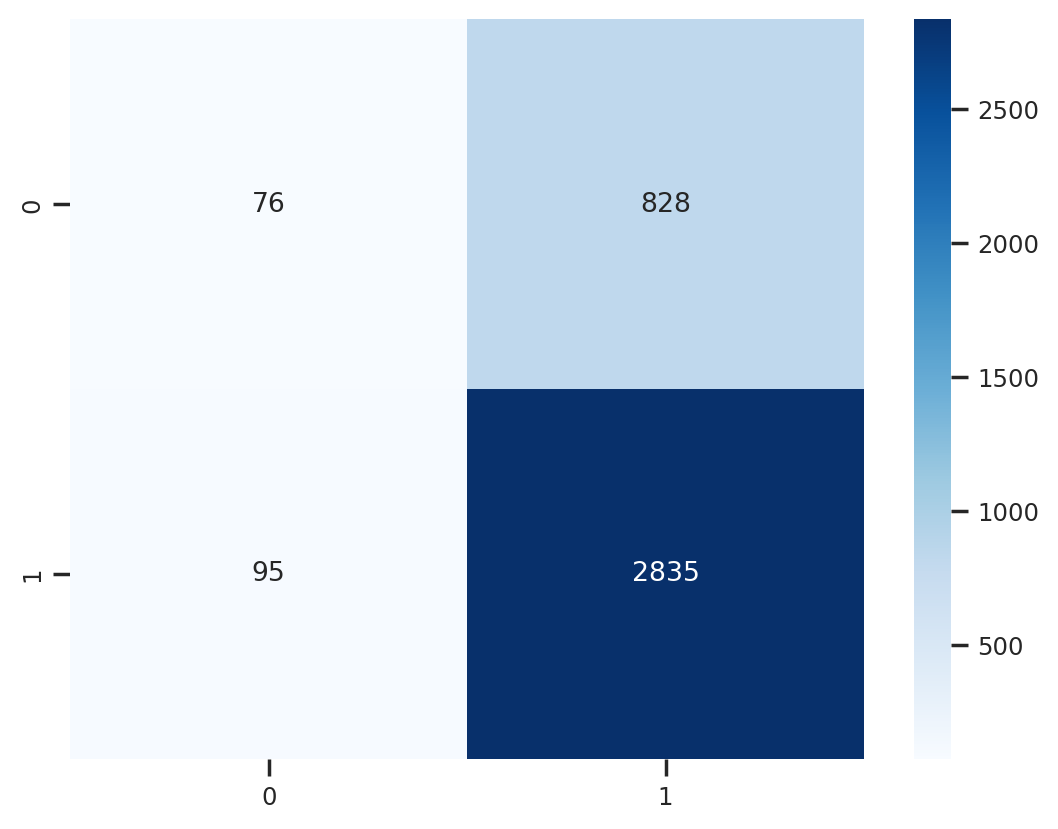

In [41]:
# Visualize the confusion matrix as a seaborn heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data = cm, annot=True, cmap="Blues", fmt="d")
plt.show()

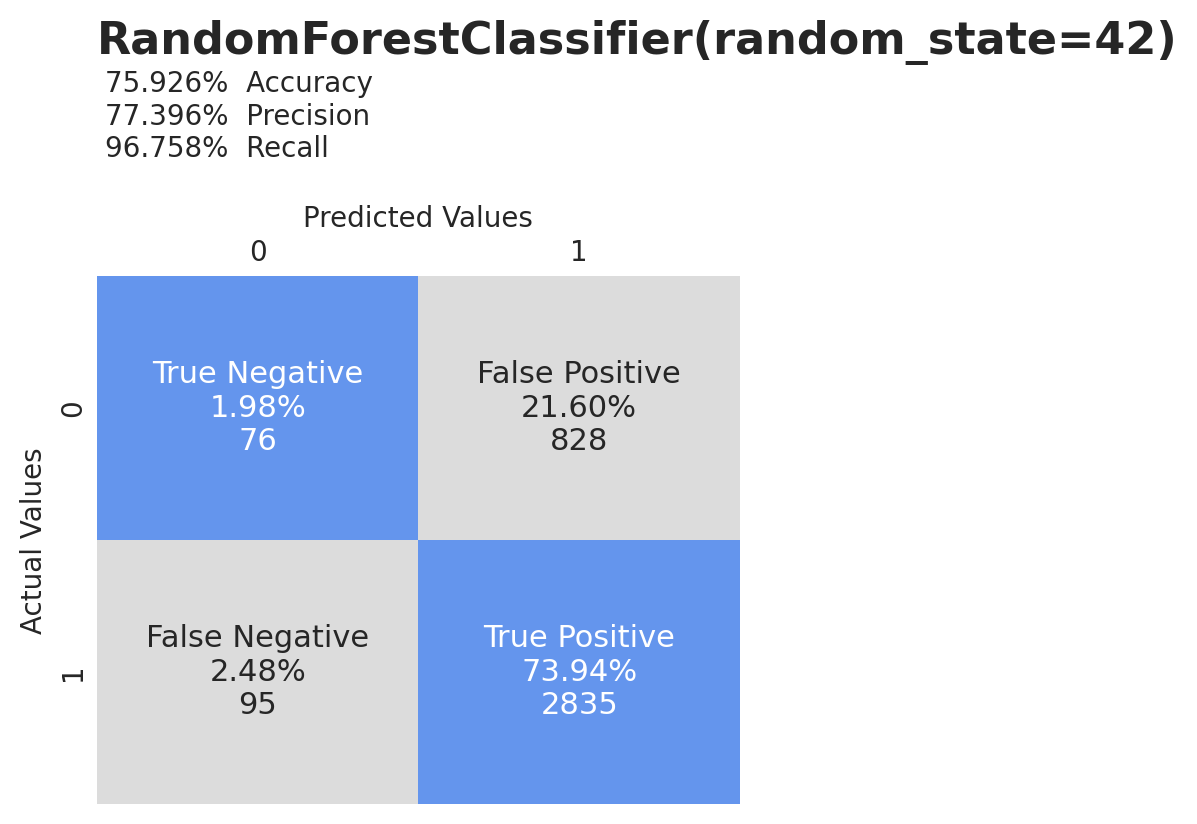

In [42]:
# Generate a better custom Confusion Matrix

accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100

cm = confusion_matrix(y_test, y_pred)
# Normalize true, pred, or all
cm_norm = confusion_matrix(y_test, y_pred, normalize='all')
cm_colors = sns.color_palette(['gainsboro', 'cornflowerblue'])

# axis labels for the confusion matrix plot
cm_y_labels = ['0','1'] # column labels
cm_x_labels = ['0','1'] # row labels

# Confusion matrix labels
# Review and update to match the appropriate labels for your data set
group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in cm_norm.flatten()]
group_labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
          zip(group_names, group_percentages, group_counts)]
group_labels = np.asarray(group_labels).reshape(2,2)

# Begin plot setup
fig, ax = plt.subplots(figsize=(4.2, 4.2))

# Heatmap
sns.heatmap(np.eye(2), annot=group_labels, annot_kws={'size': 11}, fmt='',
            cmap=cm_colors, cbar=False,
            yticklabels=cm_y_labels, xticklabels=cm_x_labels, ax=ax)

# Axis elements
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(labelsize=10, length=0)
ax.set_xlabel('Predicted Values', size=10)
ax.set_ylabel('Actual Values', size=10)

# Position group labels and set colors
for text_elt, group_label in zip(ax.texts, group_labels):
    ax.text(*text_elt.get_position(), '\n', color=text_elt.get_color(),
            ha='center', va='top')

# Title for each plot
# Adjust pad to provide room for the score report below title and above confusion matrix plot
plt.title(f'{model}', pad=80, loc='left', fontsize=16, fontweight='bold')

# Score reports beneath each title
# Adjust x and y to fit report
plt.figtext(0.21, 0.81, f'{accuracy:.3f}%  Accuracy\n{precision:.3f}%  Precision\n{recall:.3f}%  Recall', wrap=True, ha='left', fontsize=10)

# Disply the plot!
plt.tight_layout()
plt.subplots_adjust(left=0.2)
print('\n') # Add a blank line for improved spacing
plt.show()

# Feature Importances

An approximate measure of relevance for each feature: The proportional influence each feature had in the prediction process.



In [43]:
# Get feature importances from the trained RandomForestClassifier model
feature_importances = model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Make Feature the new index
feature_importance_df = feature_importance_df.set_index('Feature')

# Print the features and their importances
print("Feature Importances:")
feature_importance_df


Feature Importances:


,Importance
Feature,
Sales_mean,0.100
profit_margin,0.099
ship_cost_ratio,0.098
Profit_mean,0.097
tenure_days,0.091
recency_days,0.091
avg_quantity,0.070
avg_days_to_ship,0.057
avg_discount,0.054
